# Prediksi Risiko Kesehatan Berdasarkan Pola Gaya Hidup Modern Menggunakan Machine Learning

**Dataset:** `sleep_mobile_stress_dataset_15000.csv`  
**Target:** Klasifikasi 3 kelas - Risiko Rendah, Risiko Sedang, Risiko Tinggi

**Pipeline model:**
1. ANN TensorFlow/Keras `Sequential` -> TensorFlow Lite (`.tflite`) untuk aplikasi Android.
2. Deep Learning TensorFlow Functional API -> TensorFlow SavedModel untuk deployment produksi.

---

> Notebook ini disusun secara bertahap dan dilengkapi penjelasan di setiap tahapan untuk keperluan laporan penulisan ilmiah.

---
## Tahap 1 — Import Library

Pada tahap ini, seluruh library yang diperlukan diimport terlebih dahulu. Library yang digunakan meliputi:
- **pandas & numpy**: manipulasi dan komputasi data
- **matplotlib & seaborn**: visualisasi data
- **scikit-learn**: preprocessing, evaluasi, dan model pembanding
- **imbalanced-learn (SMOTE)**: menangani ketidakseimbangan kelas
- **TensorFlow/Keras**: membangun ANN Sequential dan model kedua dengan Functional API
- **joblib & json**: menyimpan konfigurasi preprocessing

In [1]:
# ─── Import Library ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print("Semua library berhasil diimport.")

TensorFlow version : 2.10.0
Keras version      : 2.10.0
Semua library berhasil diimport.


---
## Tahap 2 — Load Dataset

Dataset dimuat menggunakan `pandas.read_csv()`. Selanjutnya dilakukan eksplorasi awal untuk memahami struktur data, meliputi jumlah baris dan kolom, nama kolom, tipe data, statistik deskriptif, serta pengecekan nilai kosong dan duplikasi.

In [2]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
# Sesuaikan path file dataset jika diperlukan
df = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')

print("=" * 55)
print("INFORMASI AWAL DATASET")
print("=" * 55)
print(f"Jumlah baris    : {df.shape[0]:,}")
print(f"Jumlah kolom    : {df.shape[1]}")
print(f"Nama kolom      : {list(df.columns)}")

print("\n5 Data Teratas:")
display(df.head())

print("\nTipe Data Setiap Kolom:")
display(df.dtypes.to_frame(name='Tipe Data'))

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nJumlah Missing Values per Kolom:")
display(df.isnull().sum().to_frame(name='Missing Values'))

print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

INFORMASI AWAL DATASET
Jumlah baris    : 15,000
Jumlah kolom    : 13
Nama kolom      : ['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score']

5 Data Teratas:


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99



Tipe Data Setiap Kolom:


,Tipe Data
user_id,int64
age,int64
gender,object
occupation,object
daily_screen_time_hours,float64
phone_usage_before_sleep_minutes,int64
sleep_duration_hours,float64
sleep_quality_score,float64
stress_level,float64
caffeine_intake_cups,int64



Statistik Deskriptif:


,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000



Jumlah Missing Values per Kolom:


,Missing Values
user_id,0
age,0
gender,0
occupation,0
daily_screen_time_hours,0
phone_usage_before_sleep_minutes,0
sleep_duration_hours,0
sleep_quality_score,0
stress_level,0
caffeine_intake_cups,0



Jumlah Data Duplikat: 0


---
## Tahap 3 — Data Understanding

Pada tahap ini, setiap fitur utama yang akan digunakan dalam model dijelaskan secara singkat beserta relevansinya terhadap prediksi risiko kesehatan.

| Fitur | Deskripsi | Relevansi |
|---|---|---|
| `daily_screen_time_hours` | Total waktu penggunaan layar per hari (jam) | Penggunaan layar berlebihan berkaitan dengan gangguan tidur dan stres |
| `phone_usage_before_sleep_minutes` | Durasi penggunaan HP sebelum tidur (menit) | Cahaya biru dari layar mengganggu produksi melatonin sehingga menurunkan kualitas tidur |
| `sleep_duration_hours` | Durasi tidur per hari (jam) | Tidur yang cukup merupakan indikator utama kesehatan fisik dan mental |
| `sleep_quality_score` | Skor kualitas tidur (skala tertentu) | Kualitas tidur yang buruk meningkatkan risiko berbagai penyakit kronis |
| `physical_activity_minutes` | Total aktivitas fisik per hari (menit) | Aktivitas fisik yang cukup menurunkan risiko penyakit kardiovaskular dan metabolik |
| `notifications_received_per_day` | Jumlah notifikasi diterima per hari | Gangguan notifikasi yang tinggi berkaitan dengan peningkatan stres dan gangguan fokus |
| `stress_level` | Tingkat stres (skala tertentu) | Stres kronis merupakan faktor risiko utama berbagai gangguan kesehatan |
| `mental_fatigue_score` | Skor kelelahan mental (skala tertentu) | Kelelahan mental yang tinggi menurunkan imunitas dan produktivitas |

In [3]:
# ─── Analisis Kolom Tambahan ───────────────────────────────────────────────────
# Identifikasi kolom yang ada di dataset
CORE_FEATURES = [
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'stress_level',
    'mental_fatigue_score'
]

# Kolom tambahan di luar fitur utama
extra_cols = [c for c in df.columns if c not in CORE_FEATURES]
print("Kolom di luar fitur utama:", extra_cols)

# Analisis singkat kolom tambahan
for col in extra_cols:
    print(f"\n--- {col} ---")
    if df[col].dtype == 'object':
        print(df[col].value_counts())
    else:
        print(df[col].describe())

Kolom di luar fitur utama: ['user_id', 'age', 'gender', 'occupation', 'caffeine_intake_cups']

--- user_id ---
count    15000.000000
mean      7500.500000
std       4330.271354
min          1.000000
25%       3750.750000
50%       7500.500000
75%      11250.250000
max      15000.000000
Name: user_id, dtype: float64

--- age ---
count    15000.000000
mean        38.488467
std         12.007970
min         18.000000
25%         28.000000
50%         38.000000
75%         49.000000
max         59.000000
Name: age, dtype: float64

--- gender ---
gender
Male      7234
Female    7181
Other      585
Name: count, dtype: int64

--- occupation ---
occupation
Manager              1962
Doctor               1922
Software Engineer    1917
Freelancer           1891
Student              1861
Researcher           1837
Designer             1813
Teacher              1797
Name: count, dtype: int64

--- caffeine_intake_cups ---
count    15000.00000
mean         1.99880
std          1.41459
min          0.0

**Keputusan Penggunaan Kolom Tambahan:**

- **`age`**: Usia dapat memengaruhi toleransi stres dan kebutuhan tidur. Kolom ini **dipertimbangkan untuk digunakan** jika tersedia dan memiliki variasi yang cukup.
- **`gender`**: Gender dapat memengaruhi pola tidur dan respons stres. Jika digunakan, akan di-encode dengan `LabelEncoder`.
- **`occupation`**: Pekerjaan berkaitan dengan paparan stres dan gaya hidup digital. Namun, karena kategorinya banyak dan fokus penelitian adalah perilaku (bukan demografis pekerjaan), kolom ini **tidak digunakan** agar model tetap generalizable.

> Kolom `age` dan `gender` akan diikutsertakan dalam analisis korelasi untuk memutuskan secara data-driven apakah relevan.

---
## Tahap 4 — Pembersihan Data

Pembersihan data (data cleaning) dilakukan untuk memastikan kualitas data sebelum masuk ke tahap pemodelan. Tahap ini meliputi penanganan nilai kosong, data duplikat, outlier, dan validasi tipe data.

Missing values per kolom:
Tidak ditemukan missing values.

Jumlah duplikasi: 0
Baris setelah pembersihan duplikasi: 15,000

Deteksi Outlier (IQR):
  daily_screen_time_hours: 0 outlier (batas [-3.49, 14.51])
  phone_usage_before_sleep_minutes: 0 outlier (batas [-62.50, 181.50])
  sleep_duration_hours: 0 outlier (batas [1.46, 11.59])
  sleep_quality_score: 9 outlier (batas [1.25, 11.25])
  physical_activity_minutes: 0 outlier (batas [-61.00, 179.00])
  notifications_received_per_day: 0 outlier (batas [-116.50, 439.50])
  stress_level: 0 outlier (batas [-3.12, 17.88])
  mental_fatigue_score: 0 outlier (batas [-2.42, 16.57])


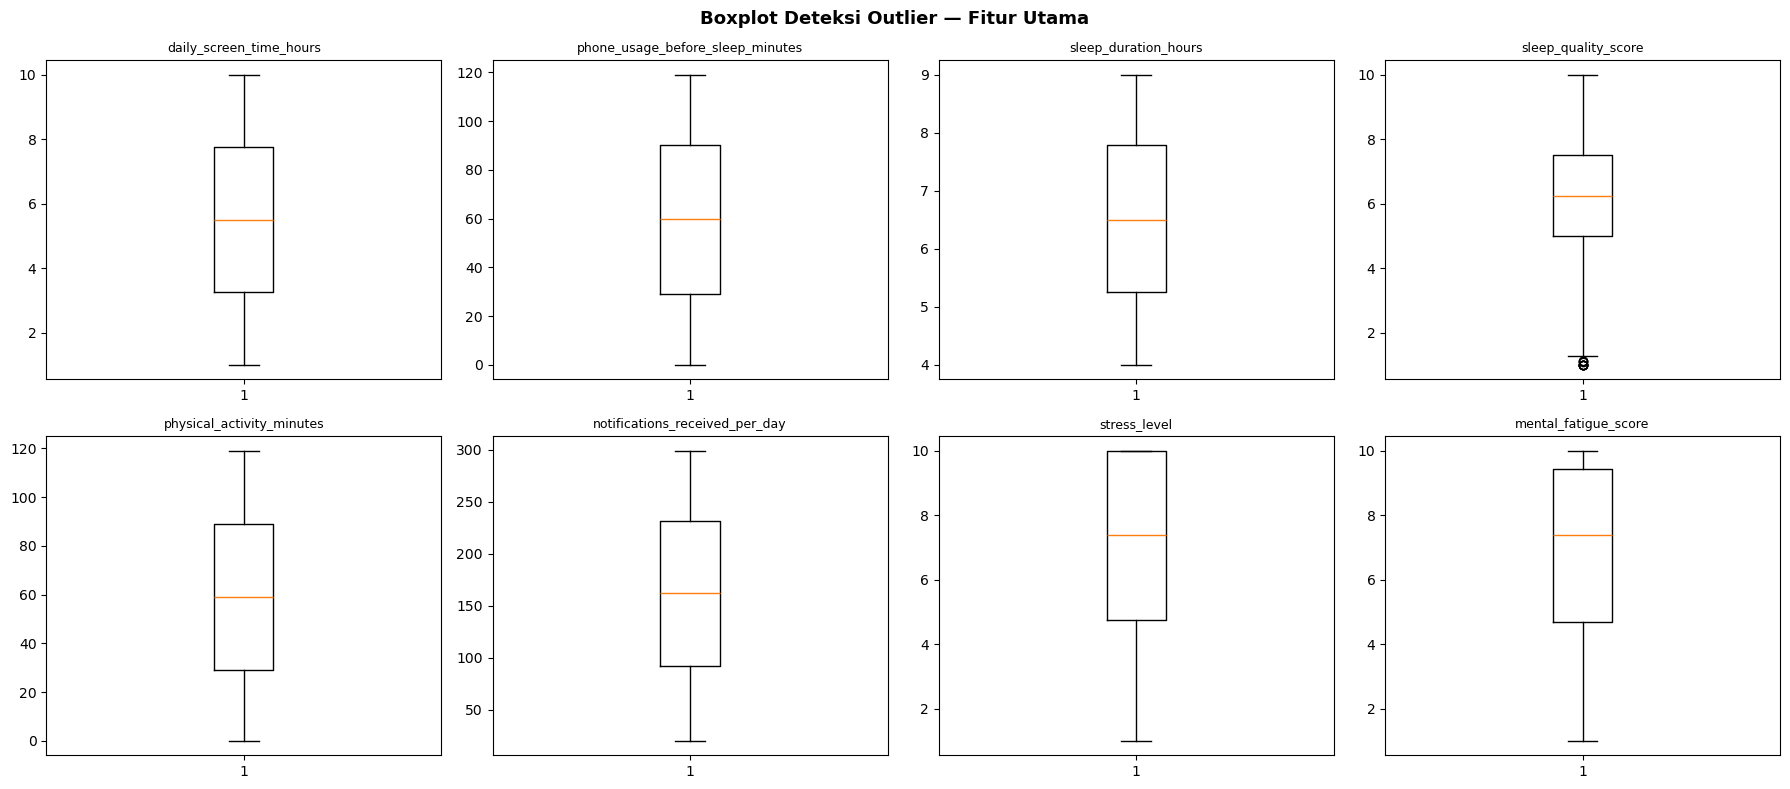


Oulier pada fitur utama umumnya merepresentasikan variasi nyata dalam gaya hidup,
sehingga TIDAK dihapus agar model dapat mempelajari pola ekstrem tersebut.

Dataset bersih: 15,000 baris × 13 kolom


In [4]:
# ─── Pembersihan Data ─────────────────────────────────────────────────────────

# 1. Salin dataset agar data asli tidak termodifikasi
df_clean = df.copy()

# 2. Tangani Missing Values
missing = df_clean.isnull().sum()
print("Missing values per kolom:")
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ditemukan missing values.")

# Isi missing values numerik dengan median, kategorik dengan modus
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"  [{col}] diisi dengan modus: {df_clean[col].mode()[0]}")
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"  [{col}] diisi dengan median: {df_clean[col].median():.2f}")

# 3. Hapus duplikasi
n_dup = df_clean.duplicated().sum()
print(f"\nJumlah duplikasi: {n_dup}")
df_clean.drop_duplicates(inplace=True)
print(f"Baris setelah pembersihan duplikasi: {len(df_clean):,}")

# 4. Deteksi Outlier menggunakan IQR pada fitur utama numerik
print("\nDeteksi Outlier (IQR):")
outlier_info = {}
for col in CORE_FEATURES:
    if col in df_clean.columns and df_clean[col].dtype != 'object':
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_out = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
        outlier_info[col] = n_out
        print(f"  {col}: {n_out} outlier (batas [{lower:.2f}, {upper:.2f}])")

# Visualisasi Boxplot
available_core = [c for c in CORE_FEATURES if c in df_clean.columns]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(available_core):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
plt.suptitle('Boxplot Deteksi Outlier — Fitur Utama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nOulier pada fitur utama umumnya merepresentasikan variasi nyata dalam gaya hidup,")
print("sehingga TIDAK dihapus agar model dapat mempelajari pola ekstrem tersebut.")

print(f"\nDataset bersih: {df_clean.shape[0]:,} baris × {df_clean.shape[1]} kolom")

---
## Tahap 5 — Pembentukan Label Risiko

### Logika Pembentukan `risk_score`

Karena dataset tidak memiliki label risiko kesehatan secara langsung, label dibentuk menggunakan **domain knowledge** berbasis literatur kesehatan digital. `risk_score` dihitung dalam rentang 0–100 menggunakan pendekatan **weighted scoring**.

**Formula:**

$$\text{risk\_score} = w_1 \cdot S_{screen} + w_2 \cdot S_{phone} + w_3 \cdot S_{sleep\_dur} + w_4 \cdot S_{sleep\_qual} + w_5 \cdot S_{activity} + w_6 \cdot S_{notif} + w_7 \cdot S_{stress} + w_8 \cdot S_{fatigue}$$

Di mana setiap komponen $S_x$ adalah nilai yang dinormalisasi (0–1) berdasarkan batas acuan kesehatan, dan $w_x$ adalah bobot kepentingan. Komponen dengan kondisi buruk menghasilkan nilai mendekati 1.

**Batas Acuan Kesehatan:**

| Fitur | Kondisi Baik | Kondisi Buruk |
|---|---|---|
| Screen time | < 4 jam/hari | ≥ 10 jam/hari |
| HP sebelum tidur | < 15 menit | ≥ 90 menit |
| Durasi tidur | 7–9 jam | < 5 jam atau > 10 jam |
| Kualitas tidur | skor tinggi = baik | skor rendah = buruk |
| Aktivitas fisik | ≥ 150 menit | < 20 menit |
| Notifikasi | < 50/hari | ≥ 200/hari |
| Stres | skor rendah = baik | skor tinggi = buruk |
| Mental fatigue | skor rendah = baik | skor tinggi = buruk |

Distribusi risk_score:
count    15000.000000
mean        51.579721
std         15.757103
min          6.030000
25%         39.910000
50%         52.255000
75%         63.562500
max         94.980000
Name: risk_score, dtype: float64

Distribusi risk_level:
risk_level
Risiko Sedang    9270
Risiko Rendah    3777
Risiko Tinggi    1953
Name: count, dtype: int64

Proporsi:
risk_level
Risiko Sedang     61.8 %
Risiko Rendah    25.18 %
Risiko Tinggi    13.02 %
Name: count, dtype: object


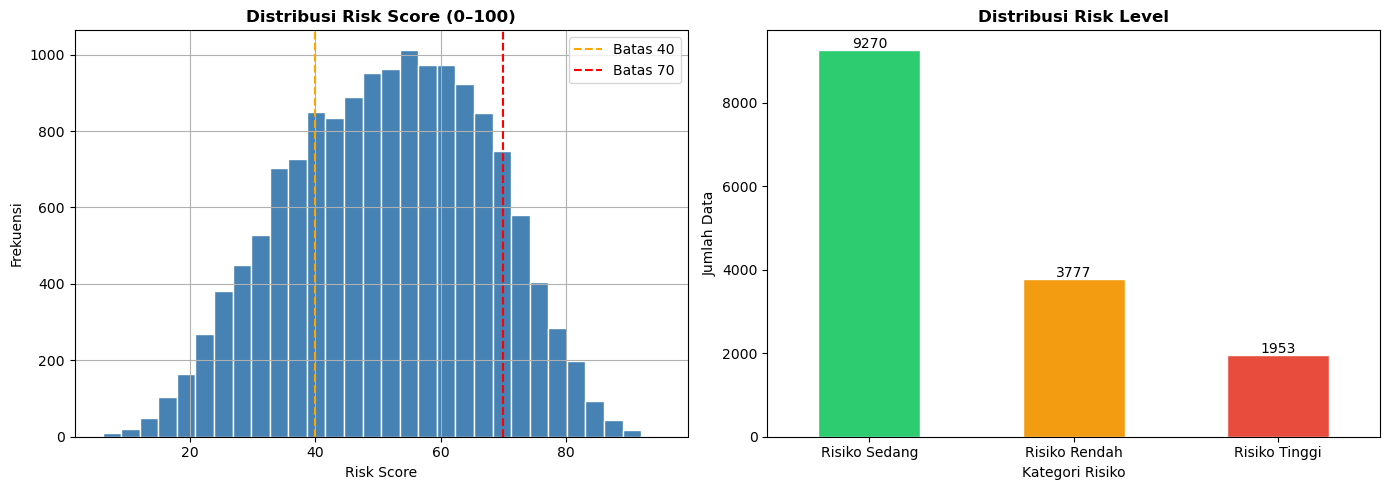

In [ ]:
# ─── Pembentukan Label Risiko ──────────────────────────────────────────────────

def normalize_clip(val, low, high, invert=False):
    """Normalisasi nilai ke rentang [0,1] menggunakan batas low-high.
    invert=True jika nilai tinggi = kondisi BAIK (akan dibalik agar tinggi = risiko tinggi)."""
    norm = (val - low) / (high - low + 1e-9)
    norm = np.clip(norm, 0, 1)
    if invert:
        norm = 1 - norm
    return norm


def compute_risk_score(row):
    """
    Menghitung risk_score dalam rentang 0–100.

    Setiap komponen dinormalisasi ke 0–1 di mana:
      - 0 = kondisi sangat baik (risiko rendah)
      - 1 = kondisi sangat buruk (risiko tinggi)

    Bobot (total = 1.0):
      screen_time          : 0.10
      phone_before_sleep   : 0.10
      sleep_duration       : 0.15  (non-linear: terlalu pendek ATAU terlalu panjang = risiko)
      sleep_quality        : 0.15
      physical_activity    : 0.15
      notifications        : 0.10
      stress_level         : 0.15
      mental_fatigue       : 0.10
    """
    score = 0.0

    # 1. Screen time harian: 0–4 jam = aman, 10+ jam = risiko penuh
    s_screen = normalize_clip(row.get('daily_screen_time_hours', 4), low=4, high=10)
    score += 0.10 * s_screen

    # 2. Penggunaan HP sebelum tidur: 0–15 menit = aman, 90+ menit = risiko penuh
    s_phone = normalize_clip(row.get('phone_usage_before_sleep_minutes', 15), low=15, high=90)
    score += 0.10 * s_phone

    # 3. Durasi tidur: optimal 7–9 jam; risiko jika < 5 atau > 10
    sleep_dur = row.get('sleep_duration_hours', 7)
    if sleep_dur < 7:
        # Kurang tidur: 7 jam = 0, 4 jam = 1
        s_sleep = normalize_clip(sleep_dur, low=7, high=4, invert=True)
        s_sleep = np.clip(1 - (sleep_dur - 4) / (7 - 4 + 1e-9), 0, 1)
    elif sleep_dur > 9:
        # Tidur berlebihan: 9 jam = 0, 11 jam = 1
        s_sleep = normalize_clip(sleep_dur, low=9, high=11)
    else:
        s_sleep = 0.0  # optimal
    score += 0.15 * s_sleep

    # 4. Kualitas tidur: asumsi skala 1–10, tinggi = baik → dibalik
    sq_min = 1; sq_max = 10
    s_squal = normalize_clip(row.get('sleep_quality_score', 7), low=sq_min, high=sq_max, invert=True)
    score += 0.15 * s_squal

    # 5. Aktivitas fisik: ≥ 150 menit = aman, 0 menit = risiko penuh → dibalik
    s_activity = normalize_clip(row.get('physical_activity_minutes', 60), low=0, high=150, invert=True)
    score += 0.15 * s_activity

    # 6. Notifikasi: 0–50 = aman, 200+ = risiko penuh
    s_notif = normalize_clip(row.get('notifications_received_per_day', 50), low=50, high=200)
    score += 0.10 * s_notif

    # 7. Tingkat stres: asumsi skala 1–10, tinggi = buruk
    stress_min = 1; stress_max = 10
    s_stress = normalize_clip(row.get('stress_level', 5), low=stress_min, high=stress_max)
    score += 0.15 * s_stress

    # 8. Mental fatigue: asumsi skala 1–10, tinggi = buruk
    mf_min = 1; mf_max = 10
    s_fatigue = normalize_clip(row.get('mental_fatigue_score', 5), low=mf_min, high=mf_max)
    score += 0.10 * s_fatigue

    return round(score * 100, 2)  # skala 0–100


# ─── Terapkan fungsi ke dataset ────────────────────────────────────────────────
df_clean['risk_score'] = df_clean.apply(compute_risk_score, axis=1)

# ─── Kategorisasi risk_level ───────────────────────────────────────────────────
def categorize_risk(score):
    if score <= 40:
        return 'Risiko Rendah'
    elif score <= 70:
        return 'Risiko Sedang'
    else:
        return 'Risiko Tinggi'

df_clean['risk_level'] = df_clean['risk_score'].apply(categorize_risk)

# nambahin sumber acuan untuk pembentukan risk_score dan risk_level
# ─── Distribusi kelas ─────────────────────────────────────────────────────────
print("Distribusi risk_score:")
print(df_clean['risk_score'].describe())

print("\nDistribusi risk_level:")
dist = df_clean['risk_level'].value_counts()
print(dist)
print(f"\nProporsi:")
print((dist / len(df_clean) * 100).round(2).astype(str) + ' %')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_clean['risk_score'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Risk Score (0–100)', fontweight='bold')
axes[0].set_xlabel('Risk Score'); axes[0].set_ylabel('Frekuensi')
axes[0].axvline(40, color='orange', linestyle='--', label='Batas 40')
axes[0].axvline(70, color='red', linestyle='--', label='Batas 70')
axes[0].legend()

colors = ['#2ecc71', '#f39c12', '#e74c3c']
dist.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Distribusi Risk Level', fontweight='bold')
axes[1].set_xlabel('Kategori Risiko'); axes[1].set_ylabel('Jumlah Data')
axes[1].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[1].patches, dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## Tahap 6 — Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami distribusi data, hubungan antar fitur, dan pola yang relevan dengan prediksi risiko kesehatan. Visualisasi ini juga berguna untuk mengidentifikasi potensi masalah seperti skewness atau kelas yang tidak seimbang.

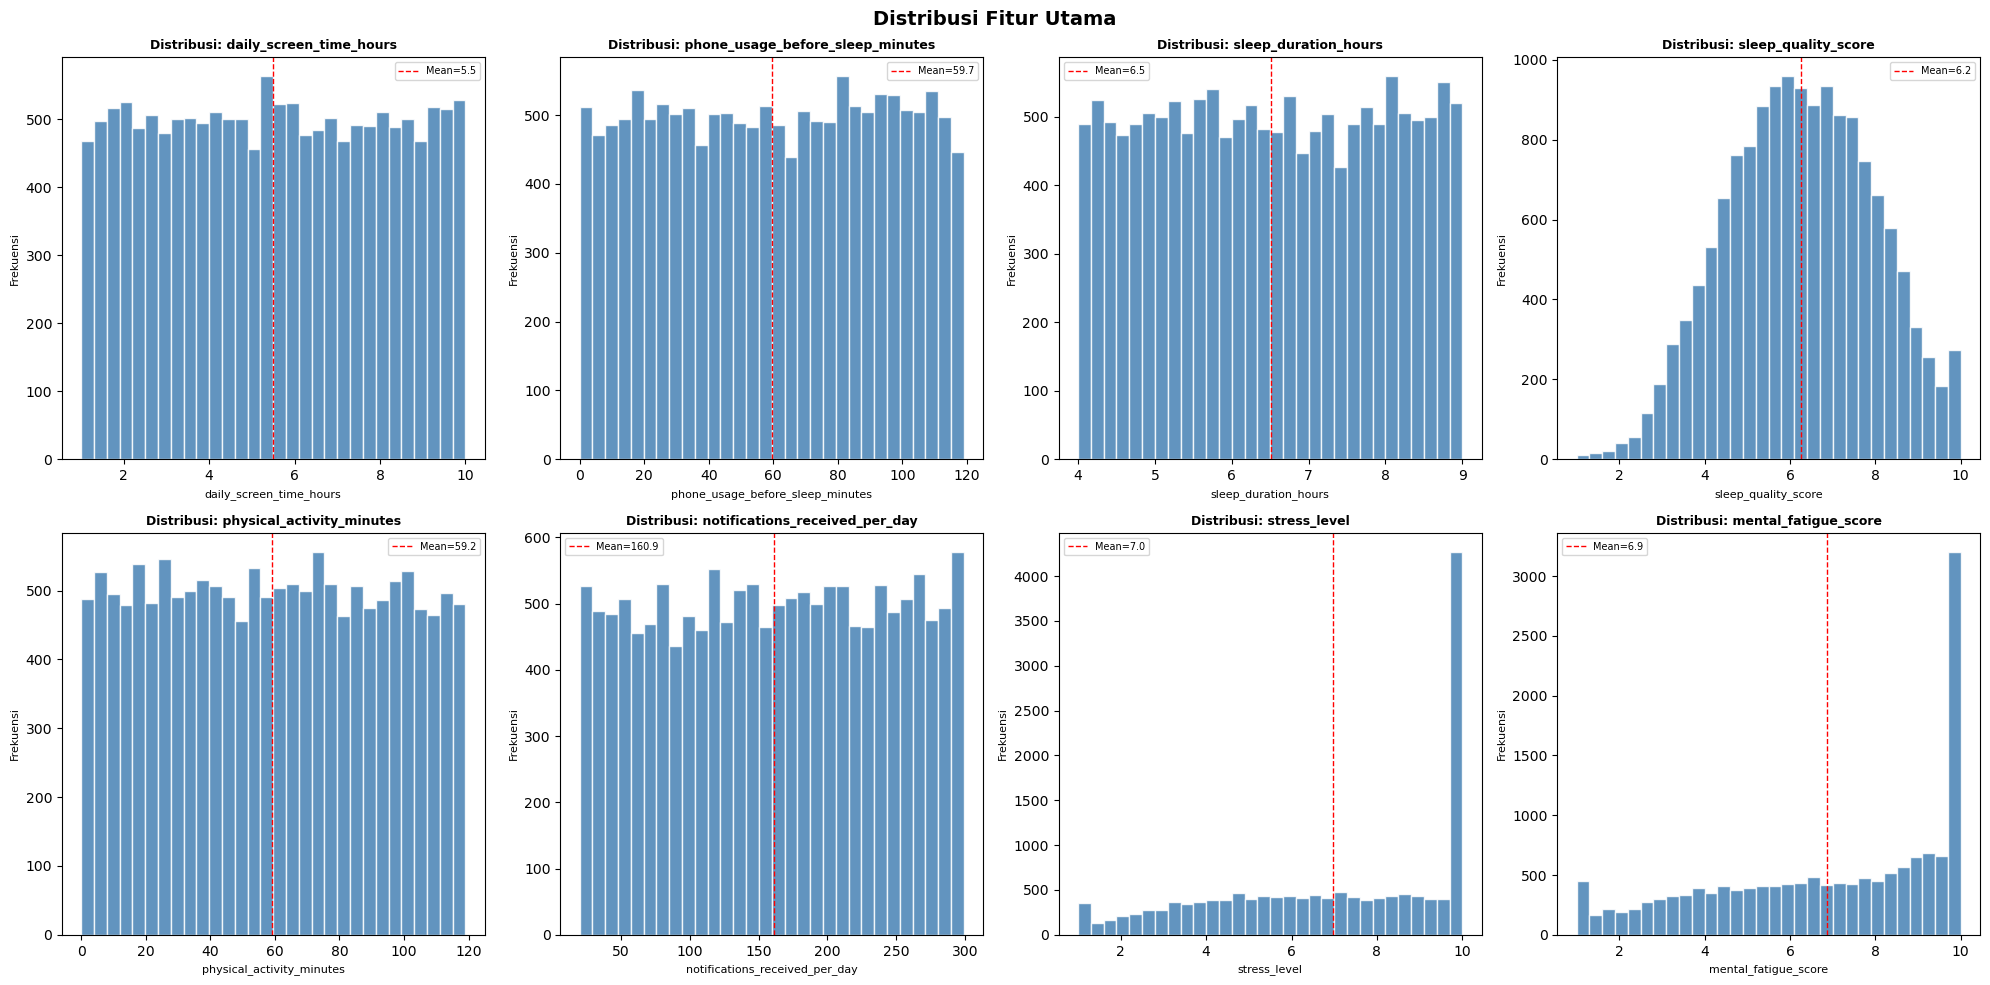

Visualisasi menunjukkan distribusi masing-masing fitur.
Garis merah menandai nilai rata-rata.


In [6]:
# ─── EDA: Distribusi Setiap Fitur Utama ───────────────────────────────────────
available_core = [c for c in CORE_FEATURES if c in df_clean.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(available_core):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Frekuensi', fontsize=8)
    mean_val = df_clean[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Distribusi Fitur Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Visualisasi menunjukkan distribusi masing-masing fitur.")
print("Garis merah menandai nilai rata-rata.")

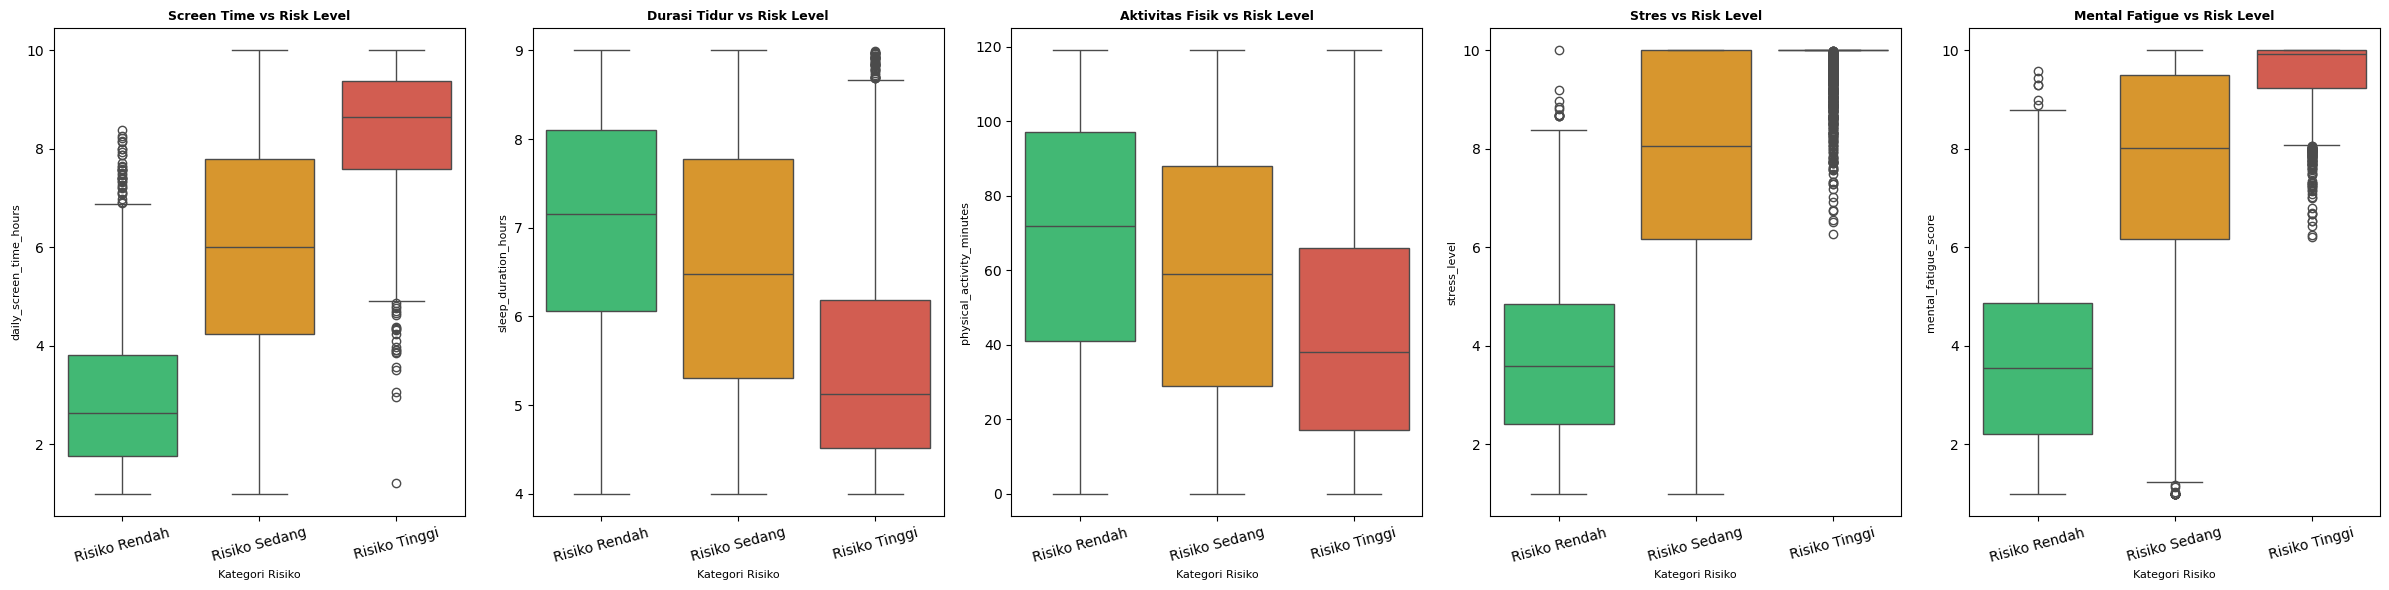

Semakin tinggi risiko, semakin tinggi screen time, stres, dan mental fatigue,
sedangkan durasi tidur dan aktivitas fisik justru semakin rendah.


In [7]:
# ─── EDA: Hubungan Fitur Terhadap Risk Level (Boxplot) ────────────────────────
key_features = [
    ('daily_screen_time_hours', 'Screen Time vs Risk Level'),
    ('sleep_duration_hours', 'Durasi Tidur vs Risk Level'),
    ('physical_activity_minutes', 'Aktivitas Fisik vs Risk Level'),
    ('stress_level', 'Stres vs Risk Level'),
    ('mental_fatigue_score', 'Mental Fatigue vs Risk Level'),
]

risk_order = ['Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']
palette = {'Risiko Rendah': '#2ecc71', 'Risiko Sedang': '#f39c12', 'Risiko Tinggi': '#e74c3c'}

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
for ax, (col, title) in zip(axes, key_features):
    if col in df_clean.columns:
        sns.boxplot(data=df_clean, x='risk_level', y=col,
                    order=risk_order, palette=palette, ax=ax)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xlabel('Kategori Risiko', fontsize=8)
        ax.set_ylabel(col, fontsize=8)
        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
print("Semakin tinggi risiko, semakin tinggi screen time, stres, dan mental fatigue,")
print("sedangkan durasi tidur dan aktivitas fisik justru semakin rendah.")

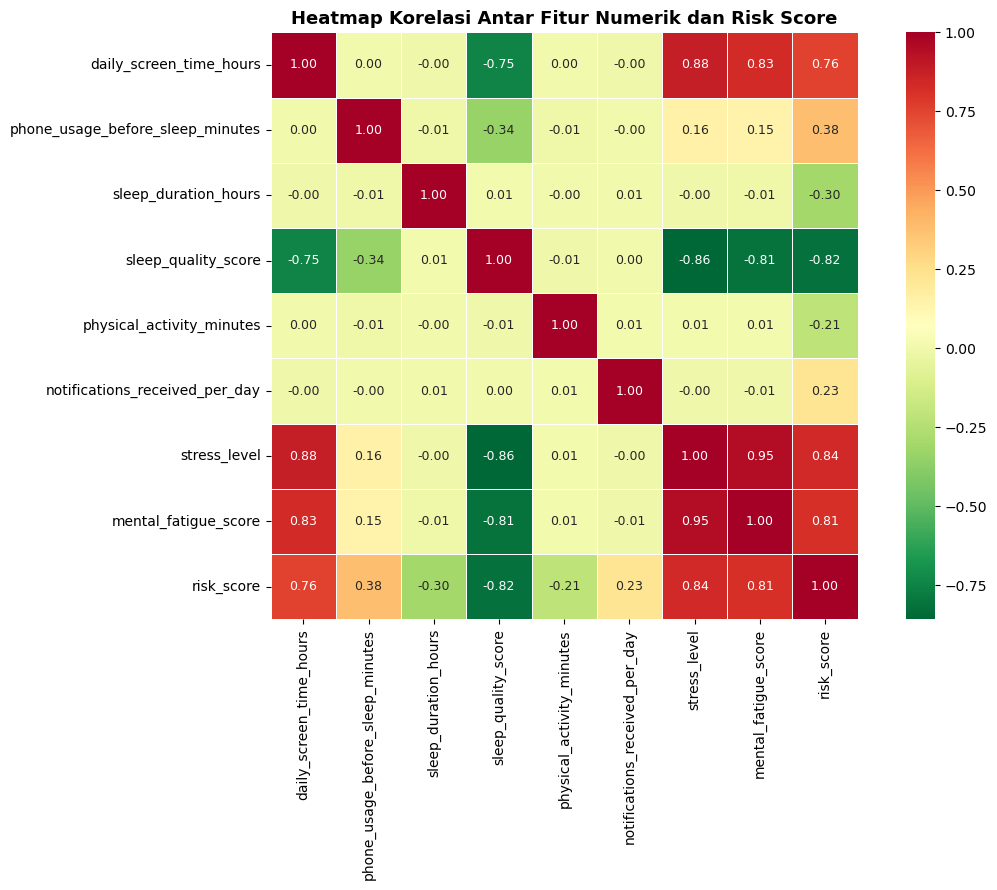

Heatmap menunjukkan korelasi linier antar fitur.
Korelasi positif kuat terhadap risk_score mengindikasikan fitur yang paling berpengaruh.


In [8]:
# ─── EDA: Heatmap Korelasi ────────────────────────────────────────────────────
num_cols = [c for c in available_core if df_clean[c].dtype != 'object'] + ['risk_score']

plt.figure(figsize=(12, 9))
corr_matrix = df_clean[num_cols].corr()

# Heatmap full kotak: mask dihapus agar seluruh matriks korelasi tampil
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9}
)

plt.title('Heatmap Korelasi Antar Fitur Numerik dan Risk Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Heatmap menunjukkan korelasi linier antar fitur.")
print("Korelasi positif kuat terhadap risk_score mengindikasikan fitur yang paling berpengaruh.")


---
## Tahap 7 - Preprocessing Data

Preprocessing adalah langkah transformasi data mentah menjadi format yang siap digunakan untuk melatih model machine learning. Tahapan ini meliputi:
1. Pemisahan fitur input (`X`) dan target (`y`)
2. Encoding target label ke integer untuk 3 kelas risiko
3. Encoding fitur kategorikal jika ada
4. Pembagian awal data menjadi data latih dan data uji (80:20, stratified)
5. Normalisasi fitur dengan Min-Max Scaler (`fit_transform` hanya pada data latih, `transform` pada data uji)
6. Pembagian data latih menjadi training internal dan validation (stratified)
7. Penanganan ketidakseimbangan kelas dengan SMOTE hanya pada training internal

Validation dan test tetap menggunakan distribusi data asli agar evaluasi tidak bias oleh data sintetis.


In [9]:
# Preprocessing

# 1. Tentukan kolom yang akan digunakan sebagai fitur
# Mulai dengan 8 fitur utama
FEATURES_USED = [c for c in CORE_FEATURES if c in df_clean.columns]

# Tambahkan 'age' dan 'gender' jika tersedia dan korelasinya signifikan
optional_features = []
if 'age' in df_clean.columns and df_clean['age'].dtype != 'object':
    corr_age = abs(df_clean['age'].corr(df_clean['risk_score']))
    if corr_age >= 0.05:
        optional_features.append('age')
        print(f"'age' diikutsertakan (korelasi dengan risk_score: {corr_age:.3f})")
    else:
        print(f"'age' tidak diikutsertakan (korelasi terlalu rendah: {corr_age:.3f})")

if 'gender' in df_clean.columns:
    optional_features.append('gender')
    print("'gender' diikutsertakan (akan di-encode)")

# 2. Encoding kolom kategorikal (gender, dll.)
categorical_mapping = {}
for col in optional_features:
    if df_clean[col].dtype == 'object':
        le = LabelEncoder()
        df_clean[col + '_enc'] = le.fit_transform(df_clean[col])
        categorical_mapping[col] = {cls: int(idx) for idx, cls in enumerate(le.classes_)}
        FEATURES_USED.append(col + '_enc')
        print(f"  {col} di-encode: {categorical_mapping[col]}")
    else:
        FEATURES_USED.append(col)

print(f"\nFitur yang digunakan ({len(FEATURES_USED)} fitur):\n{FEATURES_USED}")

# 3. Pisahkan X dan y
X = df_clean[FEATURES_USED].values
y_raw = df_clean['risk_level'].values

# 4. Encoding label target ke 3 kelas
label_order = ['Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']
label_to_int = {label: idx for idx, label in enumerate(label_order)}
int_to_label = {idx: label for label, idx in label_to_int.items()}
y = np.array([label_to_int[lbl] for lbl in y_raw])
print(f"\nEncoding label: {label_to_int}")

# Helper untuk menampilkan distribusi kelas secara konsisten
def print_class_distribution(title, labels, label_map):
    print(f"\n{title}")
    unique, counts = np.unique(labels, return_counts=True)
    total = len(labels)
    for cls_idx, cls_name in label_map.items():
        count = counts[unique.tolist().index(cls_idx)] if cls_idx in unique else 0
        print(f"  {cls_name}: {count} ({count / total * 100:.1f}%)")

# 5. Split awal: 80% data latih, 20% data uji (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"\nData latih awal : {X_train.shape[0]:,} sampel")
print(f"Data uji        : {X_test.shape[0]:,} sampel")
print_class_distribution("Distribusi kelas sebelum SMOTE (data latih awal):", y_train, int_to_label)

# 6. Normalisasi Min-Max
# fit_transform hanya pada data latih, transform pada data uji
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nNormalisasi Min-Max selesai.")
print("  fit_transform: X_train")
print("  transform    : X_test")

# 7. Split data latih menjadi training internal dan validation asli
# Validation tidak akan disentuh oleh SMOTE.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)
print(f"\nTraining internal : {X_tr.shape[0]:,} sampel")
print(f"Validation asli   : {X_val.shape[0]:,} sampel")
print_class_distribution("Distribusi kelas pada validation (tanpa SMOTE):", y_val, int_to_label)

# 8. SMOTE hanya pada training internal
smote = SMOTE(random_state=42)
X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)
print_class_distribution("Distribusi kelas setelah SMOTE pada training internal:", y_tr_smote, int_to_label)

N_FEATURES = X_tr_smote.shape[1]
N_CLASSES = len(label_order)
print(f"\nJumlah fitur input : {N_FEATURES}")
print(f"Jumlah kelas target: {N_CLASSES}")


'age' tidak diikutsertakan (korelasi terlalu rendah: 0.005)
'gender' diikutsertakan (akan di-encode)
  gender di-encode: {'Female': 0, 'Male': 1, 'Other': 2}

Fitur yang digunakan (9 fitur):
['daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'physical_activity_minutes', 'notifications_received_per_day', 'stress_level', 'mental_fatigue_score', 'gender_enc']

Encoding label: {'Risiko Rendah': 0, 'Risiko Sedang': 1, 'Risiko Tinggi': 2}

Data latih awal : 12,000 sampel
Data uji        : 3,000 sampel

Distribusi kelas sebelum SMOTE (data latih awal):
  Risiko Rendah: 3022 (25.2%)
  Risiko Sedang: 7416 (61.8%)
  Risiko Tinggi: 1562 (13.0%)

Normalisasi Min-Max selesai.
  fit_transform: X_train
  transform    : X_test

Training internal : 10,200 sampel
Validation asli   : 1,800 sampel

Distribusi kelas pada validation (tanpa SMOTE):
  Risiko Rendah: 453 (25.2%)
  Risiko Sedang: 1113 (61.8%)
  Risiko Tinggi: 234 (13.0%)

Distribusi ke

---
## Tahap 8 — Pembangunan Model TensorFlow/Keras (ANN)

Model utama dibangun menggunakan **Artificial Neural Network (ANN)** berbasis TensorFlow/Keras. Arsitektur yang digunakan:

- **Input layer**: menyesuaikan jumlah fitur
- **Hidden layers**: Dense layer dengan aktivasi ReLU dan Batch Normalization
- **Dropout**: mencegah overfitting
- **Output layer**: 3 neuron dengan aktivasi Softmax untuk klasifikasi 3 kelas
- **Loss function**: `sparse_categorical_crossentropy`
- **Optimizer**: Adam
- **Callbacks**: EarlyStopping dan ReduceLROnPlateau

In [10]:
# ─── Bangun Arsitektur Model ANN ──────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

def build_ann_model(n_features, n_classes):
    model = keras.Sequential([
        # Input Layer
        layers.Input(shape=(n_features,), name='input_layer'),

        # Hidden Layer 1
        layers.Dense(128, name='dense_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Activation('relu', name='relu_1'),
        layers.Dropout(0.3, name='dropout_1'),

        # Hidden Layer 2
        layers.Dense(64, name='dense_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Activation('relu', name='relu_2'),
        layers.Dropout(0.2, name='dropout_2'),

        # Hidden Layer 3
        layers.Dense(32, name='dense_3'),
        layers.BatchNormalization(name='bn_3'),
        layers.Activation('relu', name='relu_3'),
        layers.Dropout(0.1, name='dropout_3'),

        # Output Layer
        layers.Dense(n_classes, activation='softmax', name='output_layer')
    ], name='HealthRiskANN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_ann_model(N_FEATURES, N_CLASSES)
model.summary()

print("\nArsitektur:")
print(f"  Input  : {N_FEATURES} fitur")
print(f"  Dense 1: 128 neuron + BatchNorm + ReLU + Dropout(0.3)")
print(f"  Dense 2: 64 neuron  + BatchNorm + ReLU + Dropout(0.2)")
print(f"  Dense 3: 32 neuron  + BatchNorm + ReLU + Dropout(0.1)")
print(f"  Output : {N_CLASSES} neuron (Softmax)")

Model: "HealthRiskANN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 128)               1280      
                                                                 
 bn_1 (BatchNormalization)   (None, 128)               512       
                                                                 
 relu_1 (Activation)         (None, 128)               0         
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 bn_2 (BatchNormalization)   (None, 64)                256       
                                                                 
 relu_2 (Activation)         (None, 64)              

---
## Tahap 9 - Training Model

Model dilatih menggunakan data training internal yang sudah diseimbangkan dengan SMOTE (`X_tr_smote`, `y_tr_smote`). Data validation memakai data asli (`X_val`, `y_val`) melalui parameter `validation_data`, sehingga metrik validasi tidak dihitung dari sampel sintetis.

Callback yang digunakan adalah **EarlyStopping** (berhenti jika `val_loss` tidak membaik selama 15 epoch) dan **ReduceLROnPlateau** (menurunkan learning rate jika `val_loss` stagnan).


In [11]:
# Training
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_tr_smote, y_tr_smote,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining selesai pada epoch ke-{len(history.history['loss'])}.")


Epoch 1/150
591/591 [==============================] - 19s 25ms/step - loss: 0.3734 - accuracy: 0.8496 - val_loss: 0.2208 - val_accuracy: 0.9006 - lr: 0.0010
Epoch 2/150
591/591 [==============================] - 14s 23ms/step - loss: 0.2527 - accuracy: 0.8993 - val_loss: 0.1892 - val_accuracy: 0.9078 - lr: 0.0010
Epoch 3/150
591/591 [==============================] - 14s 25ms/step - loss: 0.2217 - accuracy: 0.9126 - val_loss: 0.1940 - val_accuracy: 0.9050 - lr: 0.0010
Epoch 4/150
591/591 [==============================] - 13s 22ms/step - loss: 0.2060 - accuracy: 0.9173 - val_loss: 0.1857 - val_accuracy: 0.9022 - lr: 0.0010
Epoch 5/150
591/591 [==============================] - 13s 22ms/step - loss: 0.2072 - accuracy: 0.9179 - val_loss: 0.1519 - val_accuracy: 0.9267 - lr: 0.0010
Epoch 6/150
591/591 [==============================] - 14s 24ms/step - loss: 0.1935 - accuracy: 0.9242 - val_loss: 0.1625 - val_accuracy: 0.9211 - lr: 0.0010
Epoch 7/150
591/591 [==============================]

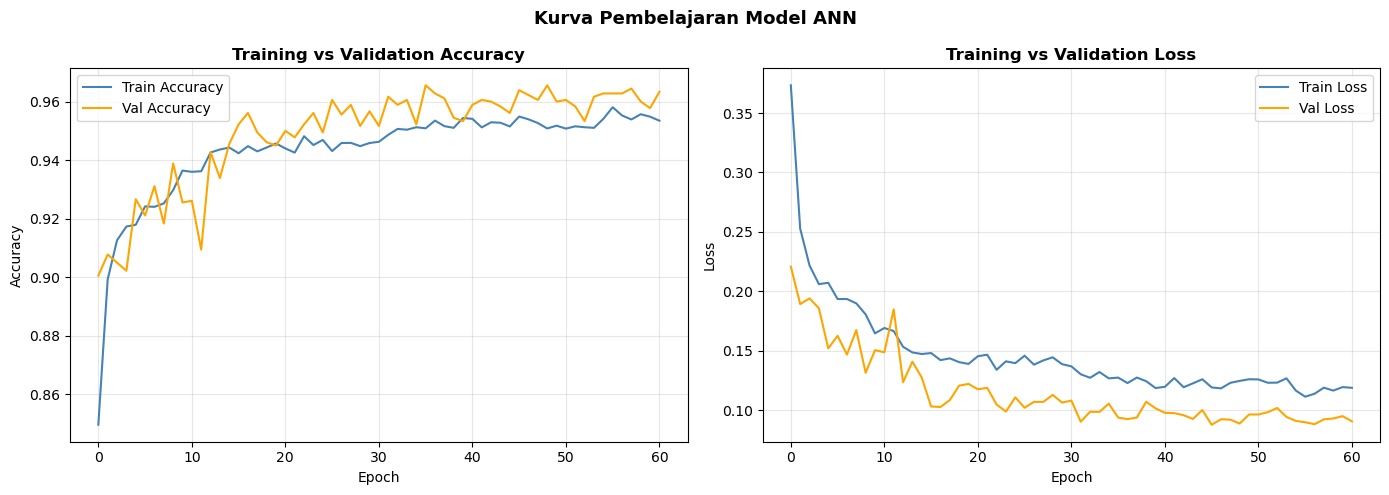


Train Accuracy final  : 0.9535
Val Accuracy final    : 0.9633
Gap                   : 0.0099
→ Model sudah cukup baik (tidak overfitting maupun underfitting secara signifikan).


In [12]:
# ─── Grafik Training ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Training vs Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Kurva Pembelajaran Model ANN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap = abs(final_train_acc - final_val_acc)
print(f"\nTrain Accuracy final  : {final_train_acc:.4f}")
print(f"Val Accuracy final    : {final_val_acc:.4f}")
print(f"Gap                   : {gap:.4f}")
if gap < 0.03:
    print("→ Model sudah cukup baik (tidak overfitting maupun underfitting secara signifikan).")
elif final_train_acc > final_val_acc + 0.05:
    print("→ Model menunjukkan gejala overfitting (gap cukup besar).")
else:
    print("→ Model konvergen dengan baik.")

---
## Tahap 10 — Evaluasi Model

Evaluasi dilakukan menggunakan data uji yang **belum pernah dilihat** model selama training. Metrik yang digunakan meliputi accuracy, precision, recall, F1-score, confusion matrix, dan AUC-ROC.

> **Perhatian khusus pada kelas Risiko Tinggi**: Dalam konteks prediksi risiko kesehatan, *false negative* pada kelas Risiko Tinggi (memprediksi seseorang berisiko rendah padahal sebenarnya berisiko tinggi) jauh lebih berbahaya. Oleh karena itu, **recall kelas Risiko Tinggi** menjadi metrik prioritas.

In [13]:
# ─── Evaluasi pada Data Uji ───────────────────────────────────────────────────
y_pred_proba = model.predict(X_test_scaled)
y_pred       = np.argmax(y_pred_proba, axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print("=" * 45)
print("HASIL EVALUASI MODEL (Data Uji)")
print("=" * 45)
print(f"Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report:")
target_names = [int_to_label[i] for i in range(N_CLASSES)]
print(classification_report(y_test, y_pred, target_names=target_names))

# Recall kelas Risiko Tinggi (kelas 2)
recalls = recall_score(y_test, y_pred, average=None)
print(f"Recall Risiko Tinggi (kelas 2): {recalls[2]:.4f}")
if recalls[2] >= 0.80:
    print("→ Recall Risiko Tinggi cukup baik (≥ 80%).")
else:
    print("→ Recall Risiko Tinggi perlu ditingkatkan (< 80%).")

94/94 [==============================] - 1s 8ms/step
HASIL EVALUASI MODEL (Data Uji)
Accuracy  : 0.9630 (96.30%)
Precision : 0.9651
Recall    : 0.9630
F1-Score  : 0.9633

Classification Report:
               precision    recall  f1-score   support

Risiko Rendah       0.95      0.98      0.96       755
Risiko Sedang       0.99      0.95      0.97      1854
Risiko Tinggi       0.88      0.99      0.93       391

     accuracy                           0.96      3000
    macro avg       0.94      0.97      0.96      3000
 weighted avg       0.97      0.96      0.96      3000

Recall Risiko Tinggi (kelas 2): 0.9923
→ Recall Risiko Tinggi cukup baik (≥ 80%).


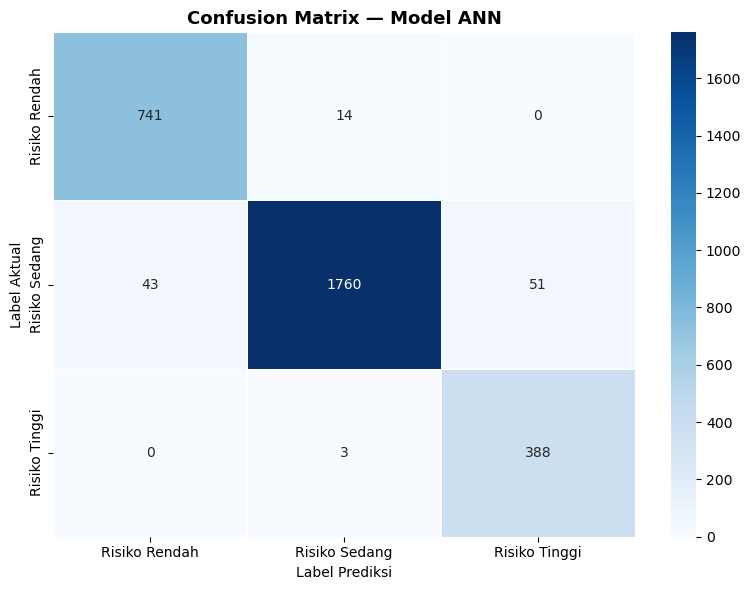

In [14]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Model ANN', fontweight='bold', fontsize=13)
plt.ylabel('Label Aktual'); plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

AUC-ROC (OvR, macro): 0.9984


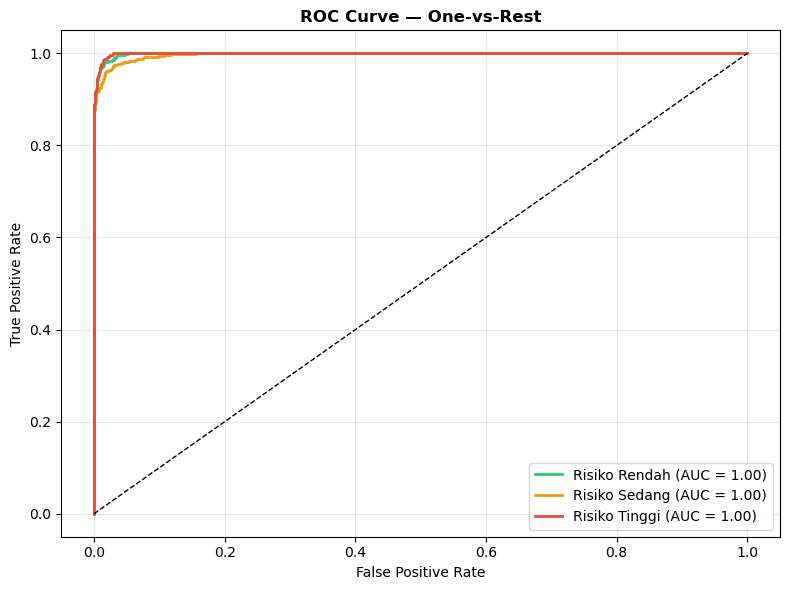

In [15]:
# ─── AUC-ROC (One-vs-Rest, Multi-kelas) ──────────────────────────────────────
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

try:
    auc_ovr = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='macro')
    print(f"AUC-ROC (OvR, macro): {auc_ovr:.4f}")

    from sklearn.metrics import roc_curve, auc
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    plt.figure(figsize=(8, 6))
    for i, (cls_name, color) in enumerate(zip(target_names, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {auc_val:.2f})')
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.title('ROC Curve — One-vs-Rest', fontweight='bold')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"AUC-ROC tidak dapat dihitung: {e}")

---
## Tahap 11 — Model Pembanding

Sebagai pembanding, dua model klasik dibuat menggunakan Logistic Regression dan Random Forest. Perbandingan ini berguna untuk mengukur nilai tambah dari penggunaan ANN sebagai model utama.

In [ ]:
# ─── Model Pembanding ─────────────────────────────────────────────────────────
results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42, multi_class='multinomial')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results['Logistic Regression'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_lr, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_lr, average='weighted'),
    'Recall Risiko Tinggi': recall_score(y_test, y_pred_lr, average=None)[2],
}

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
results['Random Forest'] = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'Recall'   : recall_score(y_test, y_pred_rf, average='weighted'),
    'F1-Score' : f1_score(y_test, y_pred_rf, average='weighted'),
    'Recall Risiko Tinggi': recall_score(y_test, y_pred_rf, average=None)[2],
}

# 3. ANN (sudah dievaluasi sebelumnya)
results['ANN (TF/Keras)'] = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'Recall Risiko Tinggi': recalls[2],
}

# Tampilkan tabel perbandingan
df_results = pd.DataFrame(results).T.round(4)
print("PERBANDINGAN PERFORMA MODEL")
display(df_results.style.highlight_max(color='lightgreen').highlight_min(color='#ffcccc'))

print("\nCatatan: Model ANN (TF/Keras) dipilih sebagai model utama karena")
print("dapat dikonversi ke format TensorFlow Lite (.tflite) untuk integrasi Android Studio.")

PERBANDINGAN PERFORMA MODEL


,Accuracy,Precision,Recall,F1-Score,Recall Risiko Tinggi
Logistic Regression,0.942000,0.942000,0.942000,0.941700,0.872100
Random Forest,0.942700,0.943300,0.942700,0.942100,0.844000
ANN (TF/Keras),0.963000,0.965100,0.963000,0.963300,0.992300



Catatan: Model ANN (TF/Keras) dipilih sebagai model utama karena
dapat dikonversi ke format TensorFlow Lite (.tflite) untuk integrasi Android Studio.


: 

---
## Tahap 12 — Interpretasi Fitur (Permutation Importance)

Analisis kontribusi fitur dilakukan menggunakan **Permutation Importance** — metode model-agnostic yang mengukur penurunan performa model ketika nilai satu fitur diacak. Fitur yang penting akan menyebabkan penurunan akurasi yang signifikan saat diacak.

In [ ]:
# ─── Permutation Importance (menggunakan Random Forest) ───────────────────────
# Random Forest digunakan untuk permutation importance karena kompatibel dengan sklearn API
perm_imp = permutation_importance(
    rf, X_test_scaled, y_test,
    n_repeats=20, random_state=42, n_jobs=-1
)

feat_imp_df = pd.DataFrame({
    'Fitur'        : FEATURES_USED,
    'Importance'   : perm_imp.importances_mean,
    'Std Dev'      : perm_imp.importances_std
}).sort_values('Importance', ascending=False)

print("Permutation Importance (Random Forest):")
display(feat_imp_df.round(4))

# Visualisasi
plt.figure(figsize=(10, 6))
colors_bar = ['#e74c3c' if i < 3 else 'steelblue' for i in range(len(feat_imp_df))]
plt.barh(feat_imp_df['Fitur'][::-1],
         feat_imp_df['Importance'][::-1],
         xerr=feat_imp_df['Std Dev'][::-1],
         color=colors_bar[::-1], edgecolor='white', capsize=4)
plt.title('Permutation Feature Importance', fontweight='bold', fontsize=13)
plt.xlabel('Rata-rata Penurunan Akurasi')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = feat_imp_df['Fitur'].head(3).tolist()
print(f"\nTiga fitur paling berpengaruh: {top3}")
print("Fitur dengan importance tinggi adalah fitur yang paling perlu diperhatikan")
print("dalam upaya pencegahan risiko kesehatan.")

---
## Tahap 13 — Simpan Model dan Konfigurasi Preprocessing

Model dan konfigurasi preprocessing disimpan agar dapat digunakan kembali tanpa perlu melatih ulang. Konfigurasi ini juga diperlukan saat membangun aplikasi Android agar proses preprocessing di aplikasi konsisten dengan saat training.

In [ ]:
# ─── Simpan Model TF/Keras ────────────────────────────────────────────────────
model.save('health_risk_model.h5')
print("Model disimpan: health_risk_model.h5")

# ─── Simpan Konfigurasi Scaler ────────────────────────────────────────────────
scaler_config = {
    'features'   : FEATURES_USED,
    'scale_'     : scaler.scale_.tolist(),
    'min_'       : scaler.min_.tolist(),
    'data_min_'  : scaler.data_min_.tolist(),
    'data_max_'  : scaler.data_max_.tolist(),
    'data_range_': scaler.data_range_.tolist(),
    'feature_range': list(scaler.feature_range)
}
with open('scaler_config.json', 'w') as f:
    json.dump(scaler_config, f, indent=2)
print("Konfigurasi scaler disimpan: scaler_config.json")

# ─── Simpan Label Mapping ─────────────────────────────────────────────────────
label_mapping = {
    'label_to_int': label_to_int,
    'int_to_label': {str(k): v for k, v in int_to_label.items()},
    'classes': target_names
}
with open('label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2, ensure_ascii=False)
print("Label mapping disimpan: label_mapping.json")

# ─── Simpan Feature Config ────────────────────────────────────────────────────
feature_config = {
    'features_used'      : FEATURES_USED,
    'n_features'         : len(FEATURES_USED),
    'categorical_mapping': categorical_mapping,
    'risk_score_weights' : {
        'daily_screen_time_hours'         : 0.10,
        'phone_usage_before_sleep_minutes': 0.10,
        'sleep_duration_hours'            : 0.15,
        'sleep_quality_score'             : 0.15,
        'physical_activity_minutes'       : 0.15,
        'notifications_received_per_day'  : 0.10,
        'stress_level'                    : 0.15,
        'mental_fatigue_score'            : 0.10
    },
    'risk_level_thresholds': {
        'Risiko Rendah': [0, 40],
        'Risiko Sedang': [41, 70],
        'Risiko Tinggi': [71, 100]
    }
}
with open('feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2, ensure_ascii=False)
print("Feature config disimpan: feature_config.json")

# ─── Simpan juga scaler dengan joblib (alternatif) ────────────────────────────
joblib.dump(scaler, 'scaler.pkl')
print("Scaler object disimpan: scaler.pkl")

---
## Tahap 14 — Konversi Model ke TensorFlow Lite

Model TensorFlow/Keras dikonversi ke format TensorFlow Lite (`.tflite`) menggunakan **TFLite Converter**. Format ini dioptimalkan untuk perangkat mobile (Android/iOS) dengan ukuran file yang lebih kecil dan inferensi yang lebih cepat.

**Dynamic Range Quantization** diterapkan untuk mereduksi ukuran model tanpa penurunan akurasi yang signifikan.

In [ ]:
# ─── Konversi ke TensorFlow Lite ──────────────────────────────────────────────

# Muat ulang model (dari file untuk memastikan konsistensi)
model_loaded = keras.models.load_model('health_risk_model.h5')

# Converter standar (tanpa quantization)
converter = tf.lite.TFLiteConverter.from_keras_model(model_loaded)
tflite_model = converter.convert()

with open('health_risk_model.tflite', 'wb') as f:
    f.write(tflite_model)
print(f"Model TFLite disimpan: health_risk_model.tflite")
print(f"Ukuran TFLite (standar): {len(tflite_model)/1024:.1f} KB")

# Converter dengan Dynamic Range Quantization
converter_quant = tf.lite.TFLiteConverter.from_keras_model(model_loaded)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_quant = converter_quant.convert()

with open('health_risk_model_quant.tflite', 'wb') as f:
    f.write(tflite_model_quant)
print(f"\nModel TFLite (quantized) disimpan: health_risk_model_quant.tflite")
print(f"Ukuran TFLite (quantized): {len(tflite_model_quant)/1024:.1f} KB")
print(f"Kompresi: {(1 - len(tflite_model_quant)/len(tflite_model))*100:.1f}% lebih kecil")
print("\nFile utama yang digunakan untuk Android: health_risk_model.tflite")

---
## Tahap 15 — Uji Model TensorFlow Lite

Model `.tflite` diuji pada beberapa sampel dari data uji untuk memastikan hasil prediksi konsisten dengan model Keras asli. Konsistensi ini penting untuk menjamin bahwa model yang digunakan di Android memberikan hasil yang sama dengan model yang dievaluasi.

In [ ]:
# ─── Uji Model TFLite ─────────────────────────────────────────────────────────

# Inisialisasi TFLite Interpreter
interpreter = tf.lite.Interpreter(model_path='health_risk_model.tflite')
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape  :", input_details[0]['shape'])
print("Input dtype  :", input_details[0]['dtype'])
print("Output shape :", output_details[0]['shape'])

def predict_tflite(interpreter, sample):
    """Prediksi satu sampel menggunakan TFLite interpreter."""
    input_data = np.array([sample], dtype=np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data[0]

# Ambil 10 sampel dari data uji
N_SAMPLES = 10
print(f"\n{'='*75}")
print(f"{'No':>3} | {'Actual':>14} | {'Keras Pred':>14} | {'TFLite Pred':>14} | {'Match':>5} | Proba TFLite")
print(f"{'='*75}")

match_count = 0
for i in range(N_SAMPLES):
    sample       = X_test_scaled[i]
    actual       = int_to_label[y_test[i]]

    # Keras prediction
    keras_proba  = model.predict(sample.reshape(1, -1), verbose=0)[0]
    keras_pred   = int_to_label[np.argmax(keras_proba)]

    # TFLite prediction
    tflite_proba = predict_tflite(interpreter, sample)
    tflite_pred  = int_to_label[np.argmax(tflite_proba)]

    match = '✓' if keras_pred == tflite_pred else '✗'
    if keras_pred == tflite_pred:
        match_count += 1

    proba_str = f"[{tflite_proba[0]:.2f}, {tflite_proba[1]:.2f}, {tflite_proba[2]:.2f}]"
    print(f"{i+1:>3} | {actual:>14} | {keras_pred:>14} | {tflite_pred:>14} | {match:>5} | {proba_str}")

print(f"{'='*75}")
print(f"Konsistensi Keras vs TFLite: {match_count}/{N_SAMPLES} ({match_count/N_SAMPLES*100:.0f}%)")
print("\nProba: [P(Risiko Rendah), P(Risiko Sedang), P(Risiko Tinggi)]")

---
## Tahap 16 - Model Deep Learning Kedua dengan TensorFlow Functional API

Bagian ini merupakan **pipeline model kedua** dan tidak menggantikan ANN `Sequential` yang sudah dibuat untuk TensorFlow Lite. Model Functional API dilatih secara mandiri menggunakan data training, validation, dan preprocessing yang sama agar hasil kedua model dapat dibandingkan secara adil.

Functional API dipilih karena mendukung arsitektur non-linear. Model berikut memakai *skip connection* sehingga representasi fitur awal dapat diteruskan ke layer yang lebih dalam. Setelah training selesai, keseluruhan graph dan bobot model diekspor dalam format **TensorFlow SavedModel** untuk deployment produksi.

In [ ]:
# Bangun Model Kedua dengan Functional API
tf.random.set_seed(42)
np.random.seed(42)

def build_functional_model(n_features, n_classes):
    inputs = keras.Input(shape=(n_features,), dtype=tf.float32, name='features')

    x = layers.Dense(128, kernel_initializer='he_normal', name='functional_dense_1')(inputs)
    x = layers.BatchNormalization(name='functional_bn_1')(x)
    x = layers.Activation('relu', name='functional_relu_1')(x)
    x = layers.Dropout(0.30, name='functional_dropout_1')(x)

    shortcut = layers.Dense(64, use_bias=False, name='shortcut_projection')(x)

    x = layers.Dense(64, kernel_initializer='he_normal', name='functional_dense_2')(x)
    x = layers.BatchNormalization(name='functional_bn_2')(x)
    x = layers.Activation('relu', name='functional_relu_2')(x)
    x = layers.Dropout(0.20, name='functional_dropout_2')(x)

    x = layers.Add(name='skip_connection')([x, shortcut])
    x = layers.Dense(32, activation='relu', name='functional_dense_3')(x)
    x = layers.Dropout(0.10, name='functional_dropout_3')(x)

    outputs = layers.Dense(
        n_classes,
        activation='softmax',
        name='risk_probabilities'
    )(x)

    functional_model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name='HealthRiskFunctionalAPI'
    )
    functional_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return functional_model


model_functional = build_functional_model(N_FEATURES, N_CLASSES)
model_functional.summary()

In [ ]:
# Training Model Functional API
functional_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

history_functional = model_functional.fit(
    X_tr_smote,
    y_tr_smote,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=functional_callbacks,
    verbose=1
)

print(
    f"Training model Functional API selesai pada "
    f"epoch ke-{len(history_functional.history['loss'])}."
)

In [ ]:
# Evaluasi Model Functional API
functional_test_loss, functional_test_accuracy = model_functional.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)
functional_pred_proba = model_functional.predict(X_test_scaled, verbose=0)
functional_pred = np.argmax(functional_pred_proba, axis=1)

functional_acc = accuracy_score(y_test, functional_pred)
functional_prec = precision_score(y_test, functional_pred, average='weighted')
functional_rec = recall_score(y_test, functional_pred, average='weighted')
functional_f1 = f1_score(y_test, functional_pred, average='weighted')
functional_recalls = recall_score(y_test, functional_pred, average=None)

print("=" * 55)
print("HASIL EVALUASI MODEL KEDUA - FUNCTIONAL API")
print("=" * 55)
print(f"Test Loss           : {functional_test_loss:.4f}")
print(f"Accuracy            : {functional_acc:.4f} ({functional_acc * 100:.2f}%)")
print(f"Precision           : {functional_prec:.4f}")
print(f"Recall              : {functional_rec:.4f}")
print(f"F1-Score            : {functional_f1:.4f}")
print(f"Recall Risiko Tinggi: {functional_recalls[2]:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, functional_pred, target_names=target_names))

comparison_deep_learning = pd.DataFrame(
    {
        'Model': ['ANN Sequential / TFLite', 'Functional API / SavedModel'],
        'Accuracy': [acc, functional_acc],
        'Precision': [prec, functional_prec],
        'Recall': [rec, functional_rec],
        'F1-Score': [f1, functional_f1],
        'Recall Risiko Tinggi': [recalls[2], functional_recalls[2]]
    }
).set_index('Model')

print("\nPerbandingan dua pipeline Deep Learning:")
display(comparison_deep_learning.round(4))

In [ ]:
# Ekspor TensorFlow SavedModel dan Verifikasi Inferensi
import os

SAVED_MODEL_DIR = 'models/saved_model/health_risk_functional'
os.makedirs(os.path.dirname(SAVED_MODEL_DIR), exist_ok=True)

@tf.function(
    input_signature=[
        tf.TensorSpec(
            shape=[None, N_FEATURES],
            dtype=tf.float32,
            name='features'
        )
    ]
)
def serve_health_risk(features):
    probabilities = model_functional(features, training=False)
    return {'risk_probabilities': probabilities}


# Signature eksplisit membuat kontrak input/output stabil untuk serving.
tf.saved_model.save(
    model_functional,
    SAVED_MODEL_DIR,
    signatures={'serving_default': serve_health_risk}
)

print(f"SavedModel disimpan di: {SAVED_MODEL_DIR}")

# Muat ulang artifact produksi tanpa bergantung pada objek model di memori.
loaded_saved_model = tf.saved_model.load(SAVED_MODEL_DIR)
available_signatures = list(loaded_saved_model.signatures.keys())
signature_name = (
    'serving_default'
    if 'serving_default' in available_signatures
    else available_signatures[0]
)
serving_fn = loaded_saved_model.signatures[signature_name]

signature_inputs = serving_fn.structured_input_signature[1]
input_name = next(iter(signature_inputs))
saved_outputs = serving_fn(
    **{
        input_name: tf.constant(
            X_test_scaled[:10],
            dtype=tf.float32
        )
    }
)
saved_probabilities = next(iter(saved_outputs.values())).numpy()
keras_probabilities = model_functional.predict(
    X_test_scaled[:10],
    verbose=0
)

is_consistent = np.allclose(
    saved_probabilities,
    keras_probabilities,
    rtol=1e-5,
    atol=1e-6
)

print(f"Signature tersedia : {available_signatures}")
print(f"Signature diuji    : {signature_name}")
print(f"Nama input         : {input_name}")
print(f"Shape output       : {saved_probabilities.shape}")
print(f"Konsisten dengan model sebelum ekspor: {is_consistent}")

assert is_consistent, "Prediksi SavedModel berbeda dari model sebelum ekspor."

---
## Tahap 17 - Kesimpulan Akhir

Pada bagian ini dirangkum kedua pipeline model, hasil evaluasi, dan artifact yang digunakan untuk aplikasi Android maupun deployment TensorFlow produksi.

In [ ]:
# Cetak Kesimpulan Akhir
print("=" * 70)
print("                    KESIMPULAN AKHIR PROJECT")
print("=" * 70)

print(f"""
1. DATASET DAN FITUR
   Dataset: 'sleep_mobile_stress_dataset_15000.csv' ({df_clean.shape[0]:,} baris)
   Jumlah fitur input: {len(FEATURES_USED)}
   Fitur: {FEATURES_USED}

2. PIPELINE MODEL 1 - ANN SEQUENTIAL UNTUK ANDROID
   Input({N_FEATURES}) -> Dense(128) -> Dense(64) -> Dense(32)
                       -> Dense({N_CLASSES}, Softmax)
   Accuracy            : {acc:.4f} ({acc * 100:.2f}%)
   F1-Score            : {f1:.4f}
   Recall Risiko Tinggi: {recalls[2]:.4f}
   Output:
     - health_risk_model.h5
     - health_risk_model.tflite
     - health_risk_model_quant.tflite

3. PIPELINE MODEL 2 - FUNCTIONAL API UNTUK PRODUKSI
   Input({N_FEATURES}) -> Dense(128) -> Dense(64) + Skip Connection
                       -> Dense(32) -> Dense({N_CLASSES}, Softmax)
   Accuracy            : {functional_acc:.4f} ({functional_acc * 100:.2f}%)
   F1-Score            : {functional_f1:.4f}
   Recall Risiko Tinggi: {functional_recalls[2]:.4f}
   Output:
     - {SAVED_MODEL_DIR}/
     - serving signature: serving_default

4. KONFIGURASI PREPROCESSING
   - feature_config.json
   - scaler_config.json
   - label_mapping.json
   - scaler.pkl

5. TARGET DEPLOYMENT
   - TFLite digunakan oleh aplikasi Android.
   - SavedModel memuat graph, bobot terlatih, dan serving signature
     untuk TensorFlow Serving atau backend berbasis TensorFlow.
""")

print("=" * 70)
print("Dua pipeline model selesai dibuat dan dievaluasi.")
print("=" * 70)